# 01 — Data Preparation

Loads the identities verified from the completed shared pool, builds a stratified
per-identity train/validation/test split, and defines the preprocessing pipeline. Before
running this notebook, verify 4–6 distinct identities with 23–25 images each using
`src/select_identities.py`. Training images are loaded only from `data/shared_pool/`.

Previously saved cell outputs show the old five-identity, 30-image experiment. They are
historical only and do not verify the current course requirement; rerun this notebook
after the completed shared pool has passed verification.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

from dataset import build_splits, CelebASubset, IMAGE_SIZE
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
LOGS_DIR = REPO_ROOT / "logs"


Matplotlib is building the font cache; this may take a moment.


## Load verified shared-pool identities

Run `python src/select_identities.py --identity-ids ... --diversity-review "..."` after the shared pool is complete. The command verifies the image-file count for every selected identity and writes `logs/selected_identities.json` only when the 23–25 requirement passes.

In [ ]:
selected_path = LOGS_DIR / "selected_identities.json"
assert selected_path.exists(), "Run the shared-pool identity verifier first."

selected = json.loads(selected_path.read_text())
assert selected.get("source") == "data/shared_pool", "Selection is not from the shared pool."
assert selected.get("counts_verified") is True, "Shared-pool image counts have not been verified."
IDENTITY_IDS = [row["identity_id"] for row in selected["selected"]]
assert 4 <= len(IDENTITY_IDS) <= 6, "Milestone requires 4-6 distinct identities."
assert len(set(IDENTITY_IDS)) == len(IDENTITY_IDS), "Selected identity IDs must be distinct."
assert all(23 <= row["num_images"] <= 25 for row in selected["selected"]), "Each identity must have 23-25 images."

print("Using verified shared-pool identities:", IDENTITY_IDS)
for row in selected["selected"]:
    print(f"  id={row['identity_id']:>6}  shared_pool_images={row['num_images']:>2}")

Using identities: [6439, 5640, 6195, 5485, 7087]
  id=  6439  n_images= 30  attrs=['Blond_Hair']
  id=  5640  n_images= 30  attrs=['Male', 'Gray_Hair', 'Eyeglasses', 'Bald']
  id=  6195  n_images= 30  attrs=['Male', 'Black_Hair', 'Mustache']
  id=  5485  n_images= 30  attrs=['Male', 'Eyeglasses', 'Wearing_Hat']
  id=  7087  n_images= 30  attrs=['Black_Hair', 'Eyeglasses']


## Build the stratified train/val/test split (15% val, 15% test, per identity)

In [3]:
splits_df = build_splits(IDENTITY_IDS, val_frac=0.15, test_frac=0.15, seed=42)
print(splits_df.groupby(["identity", "split"]).size().unstack(fill_value=0))


split     test  train  val
identity                  
5485         4     22    4
5640         4     22    4
6195         4     22    4
6439         4     22    4
7087         4     22    4


## Sanity-check a batch of preprocessed/augmented training images

train=110  val=20  test=20  num_classes=5


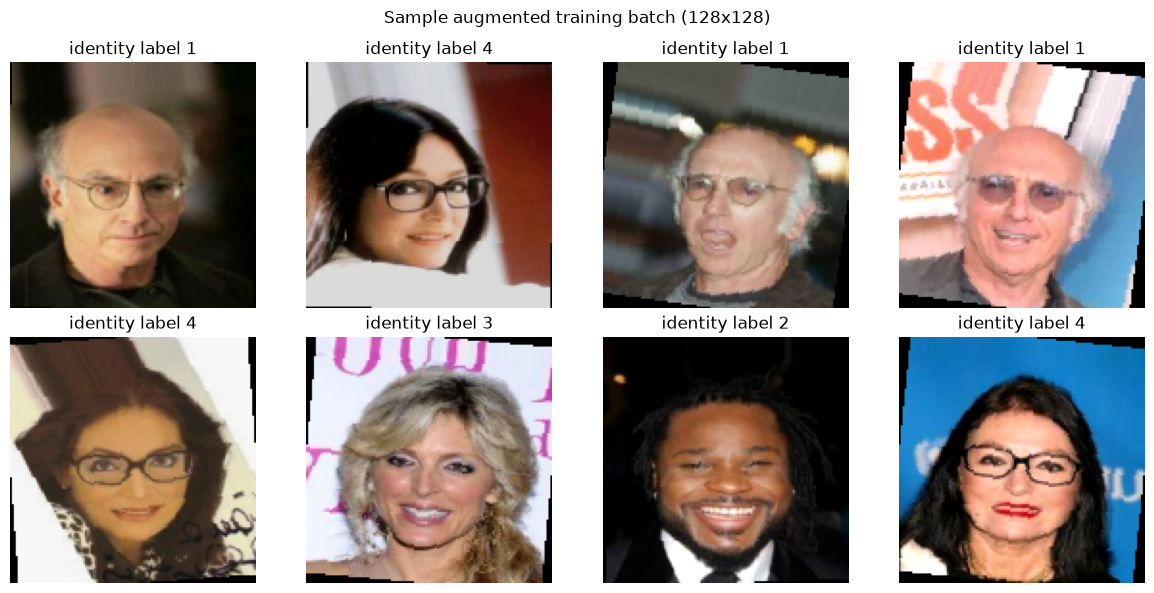

In [4]:
import torch
from torch.utils.data import DataLoader

train_ds = CelebASubset("train", splits_df)
val_ds = CelebASubset("val", splits_df)
test_ds = CelebASubset("test", splits_df)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}  num_classes={train_ds.num_classes}")

loader = DataLoader(train_ds, batch_size=8, shuffle=True)
images, labels = next(iter(loader))

# undo normalization for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for img, label, ax in zip(images, labels, axes.flatten()):
    img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"identity label {label.item()}")
    ax.axis("off")
fig.suptitle(f"Sample augmented training batch ({IMAGE_SIZE}x{IMAGE_SIZE})")
fig.tight_layout()
fig.savefig(LOGS_DIR / "sample_batch.png", dpi=150)
plt.show()


## Preprocessing pipeline summary

- **Resize**: all images resized to 128x128 (kept small for CPU-friendly training on
  Explorer's older CPU nodes / limited local hardware).
- **Normalization**: ImageNet mean/std, so both the custom CNN and the pretrained
  ResNet18 see inputs in a consistent, comparable distribution.
- **Augmentation (train split only)**: random horizontal flip (p=0.5), color jitter
  (brightness/contrast/saturation), random rotation (±8°). None applied to val/test so
  evaluation numbers reflect real-world performance.
- **Split**: stratified 70/15/15 per identity, so every identity appears in all three
  splits regardless of class imbalance.

Next: `02_custom_cnn_training.ipynb` and `03_transfer_learning_resnet.ipynb`.